In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../data/processed/crypto_volatility_processed.csv")

df.head()


,open,high,low,close,volume,marketCap,close_lag_1,close_lag_7,vol_lag_1,volatility_14d,ma_7,bb_middle,bb_upper,bb_lower,hl_range,oc_change,liquidity_ratio,volatility_7d
0,39.455022,40.928509,37.601201,37.904761,4.397045e+07,4.048626e+08,39.455022,40.746972,0.094234,0.083418,37.204395,42.630075,54.211843,31.048308,0.087781,-0.039292,0.108606,0.095072
1,37.904763,39.163864,35.071968,36.033922,5.030722e+07,3.848801e+08,37.904761,36.012317,0.095072,0.081252,37.207481,42.311691,54.264071,30.359312,0.113557,-0.049356,0.130709,0.083948
2,36.033914,38.869182,34.469635,34.871531,5.858131e+07,3.724646e+08,36.033922,32.180017,0.083948,0.081255,37.591983,42.051069,54.427760,29.674378,0.126164,-0.032258,0.157280,0.070447
3,34.871536,35.564022,32.000059,32.394083,6.053387e+07,3.460028e+08,34.871531,35.160357,0.070447,0.081611,37.196801,41.482550,54.553001,28.412100,0.110019,-0.071045,0.174952,0.067485
4,32.394082,33.155484,28.240773,29.098334,6.630479e+07,3.108008e+08,32.394083,38.031651,0.067485,0.077185,35.920613,40.596580,54.518768,26.674391,0.168900,-0.101739,0.213335,0.062442


In [6]:
X = df.drop(columns=["volatility_7d"])
y = df["volatility_7d"]


In [7]:


X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [9]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(57012, 17) (14254, 17)
(57012,) (14254,)


In [12]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)

print("Baseline RMSE:", baseline_rmse)


Baseline RMSE: 0.04578652898195542


In [14]:
import numpy as np

np.isinf(X_train).sum()


open                  0
high                  0
low                   0
close                 0
volume                0
marketCap             0
close_lag_1           0
close_lag_7           0
vol_lag_1             0
volatility_14d        0
ma_7                  0
bb_middle             0
bb_upper              0
bb_lower              0
hl_range              0
oc_change             0
liquidity_ratio    1726
dtype: int64

In [15]:
# Drop rows with NaN in liquidity_ratio
X_train = X_train.dropna(subset=["liquidity_ratio"])
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna(subset=["liquidity_ratio"])
y_test = y_test.loc[X_test.index]


In [27]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))


In [ ]:
print(len(y_test))
print(len(baseline_pred))


13985
13985


In [16]:
print(X_train.isna().sum())
print(X_test.isna().sum())


open               0
high               0
low                0
close              0
volume             0
marketCap          0
close_lag_1        0
close_lag_7        0
vol_lag_1          0
volatility_14d     0
ma_7               0
bb_middle          0
bb_upper           0
bb_lower           0
hl_range           0
oc_change          0
liquidity_ratio    0
dtype: int64
open               0
high               0
low                0
close              0
volume             0
marketCap          0
close_lag_1        0
close_lag_7        0
vol_lag_1          0
volatility_14d     0
ma_7               0
bb_middle          0
bb_upper           0
bb_lower           0
hl_range           0
oc_change          0
liquidity_ratio    0
dtype: int64


In [18]:


X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)


In [19]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


In [20]:
print("NaNs in X_train:\n", X_train.isna().sum().sum())
print("NaNs in X_test:\n", X_test.isna().sum().sum())

print("Infs in X_train:\n", np.isinf(X_train).sum().sum())
print("Infs in X_test:\n", np.isinf(X_test).sum().sum())


NaNs in X_train:
 0
NaNs in X_test:
 0
Infs in X_train:
 0
Infs in X_test:
 0


In [29]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))
print(len(y_test))
print(len(baseline_pred))


13985
13985


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


In [23]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)


In [25]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))


In [30]:
rf_pred  = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)


In [31]:
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))


In [33]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost"],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAE": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "R2 Score": [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results


,Model,RMSE,MAE,R2 Score
0,Baseline,0.045787,0.036163,-0.157425
1,Random Forest,0.009898,0.004749,0.944238
2,XGBoost,0.010223,0.005039,0.940522


In [34]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


low               0.231199
bb_middle         0.214602
vol_lag_1         0.185881
close             0.083098
open              0.073670
bb_upper          0.055206
volatility_14d    0.036904
close_lag_7       0.034121
high              0.031076
marketCap         0.011831
dtype: float32

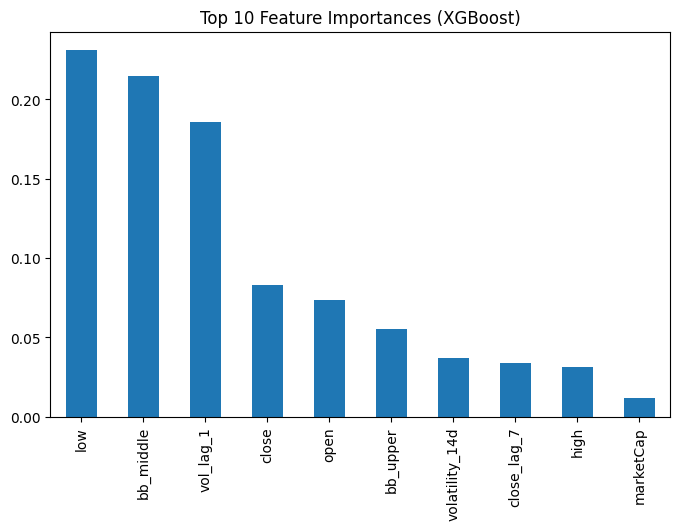

In [36]:
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()


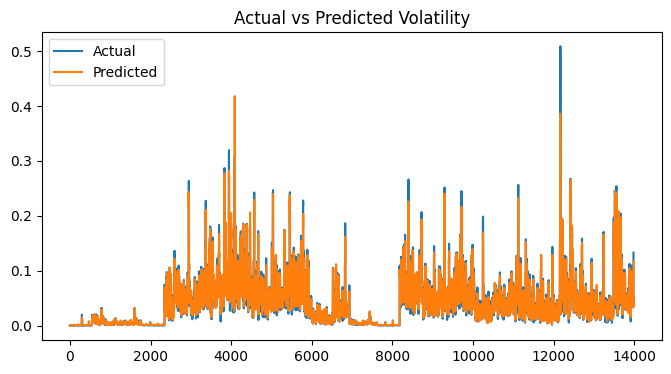

In [37]:
plt.figure(figsize=(8,4))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Volatility")
plt.show()


In [39]:
import os

os.makedirs("../models", exist_ok=True)


In [40]:
import joblib

joblib.dump(xgb_model, "../models/volatility_xgboost_model.pkl")


['../models/volatility_xgboost_model.pkl']

In [42]:
import os

os.makedirs("../results", exist_ok=True)


In [43]:
results.to_csv("../results/model_comparison.csv", index=False)


### Model Selection Conclusion

- XGBoost outperformed the baseline and Random Forest models.
- It effectively captured non-linear relationships in time-series features.
- Lagged volatility and liquidity-based features were the most influential.
- XGBoost was selected as the final model for deployment.
